# 1971. Find if Path Exists in Graph

There is a bi-directional graph with n vertices, where each vertex is labeled from 0 to n - 1 (inclusive). The edges in the graph are represented as a 2D integer array edges, where each edges[i] = [ui, vi] denotes a bi-directional edge between vertex ui and vertex vi. Every vertex pair is connected by at most one edge, and no vertex has an edge to itself.

You want to determine if there is a valid path that exists from vertex source to vertex destination.

Given edges and the integers n, source, and destination, return true if there is a valid path from source to destination, or false otherwise.

 

Example 1:

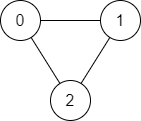

Input: n = 3, edges = [[0,1],[1,2],[2,0]], source = 0, destination = 2
Output: true
Explanation: There are two paths from vertex 0 to vertex 2:
- 0 → 1 → 2
- 0 → 2

Example 2:

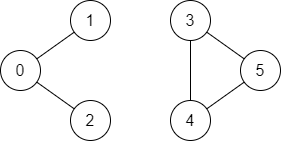

Input: n = 6, edges = [[0,1],[0,2],[3,5],[5,4],[4,3]], source = 0, destination = 5
Output: false

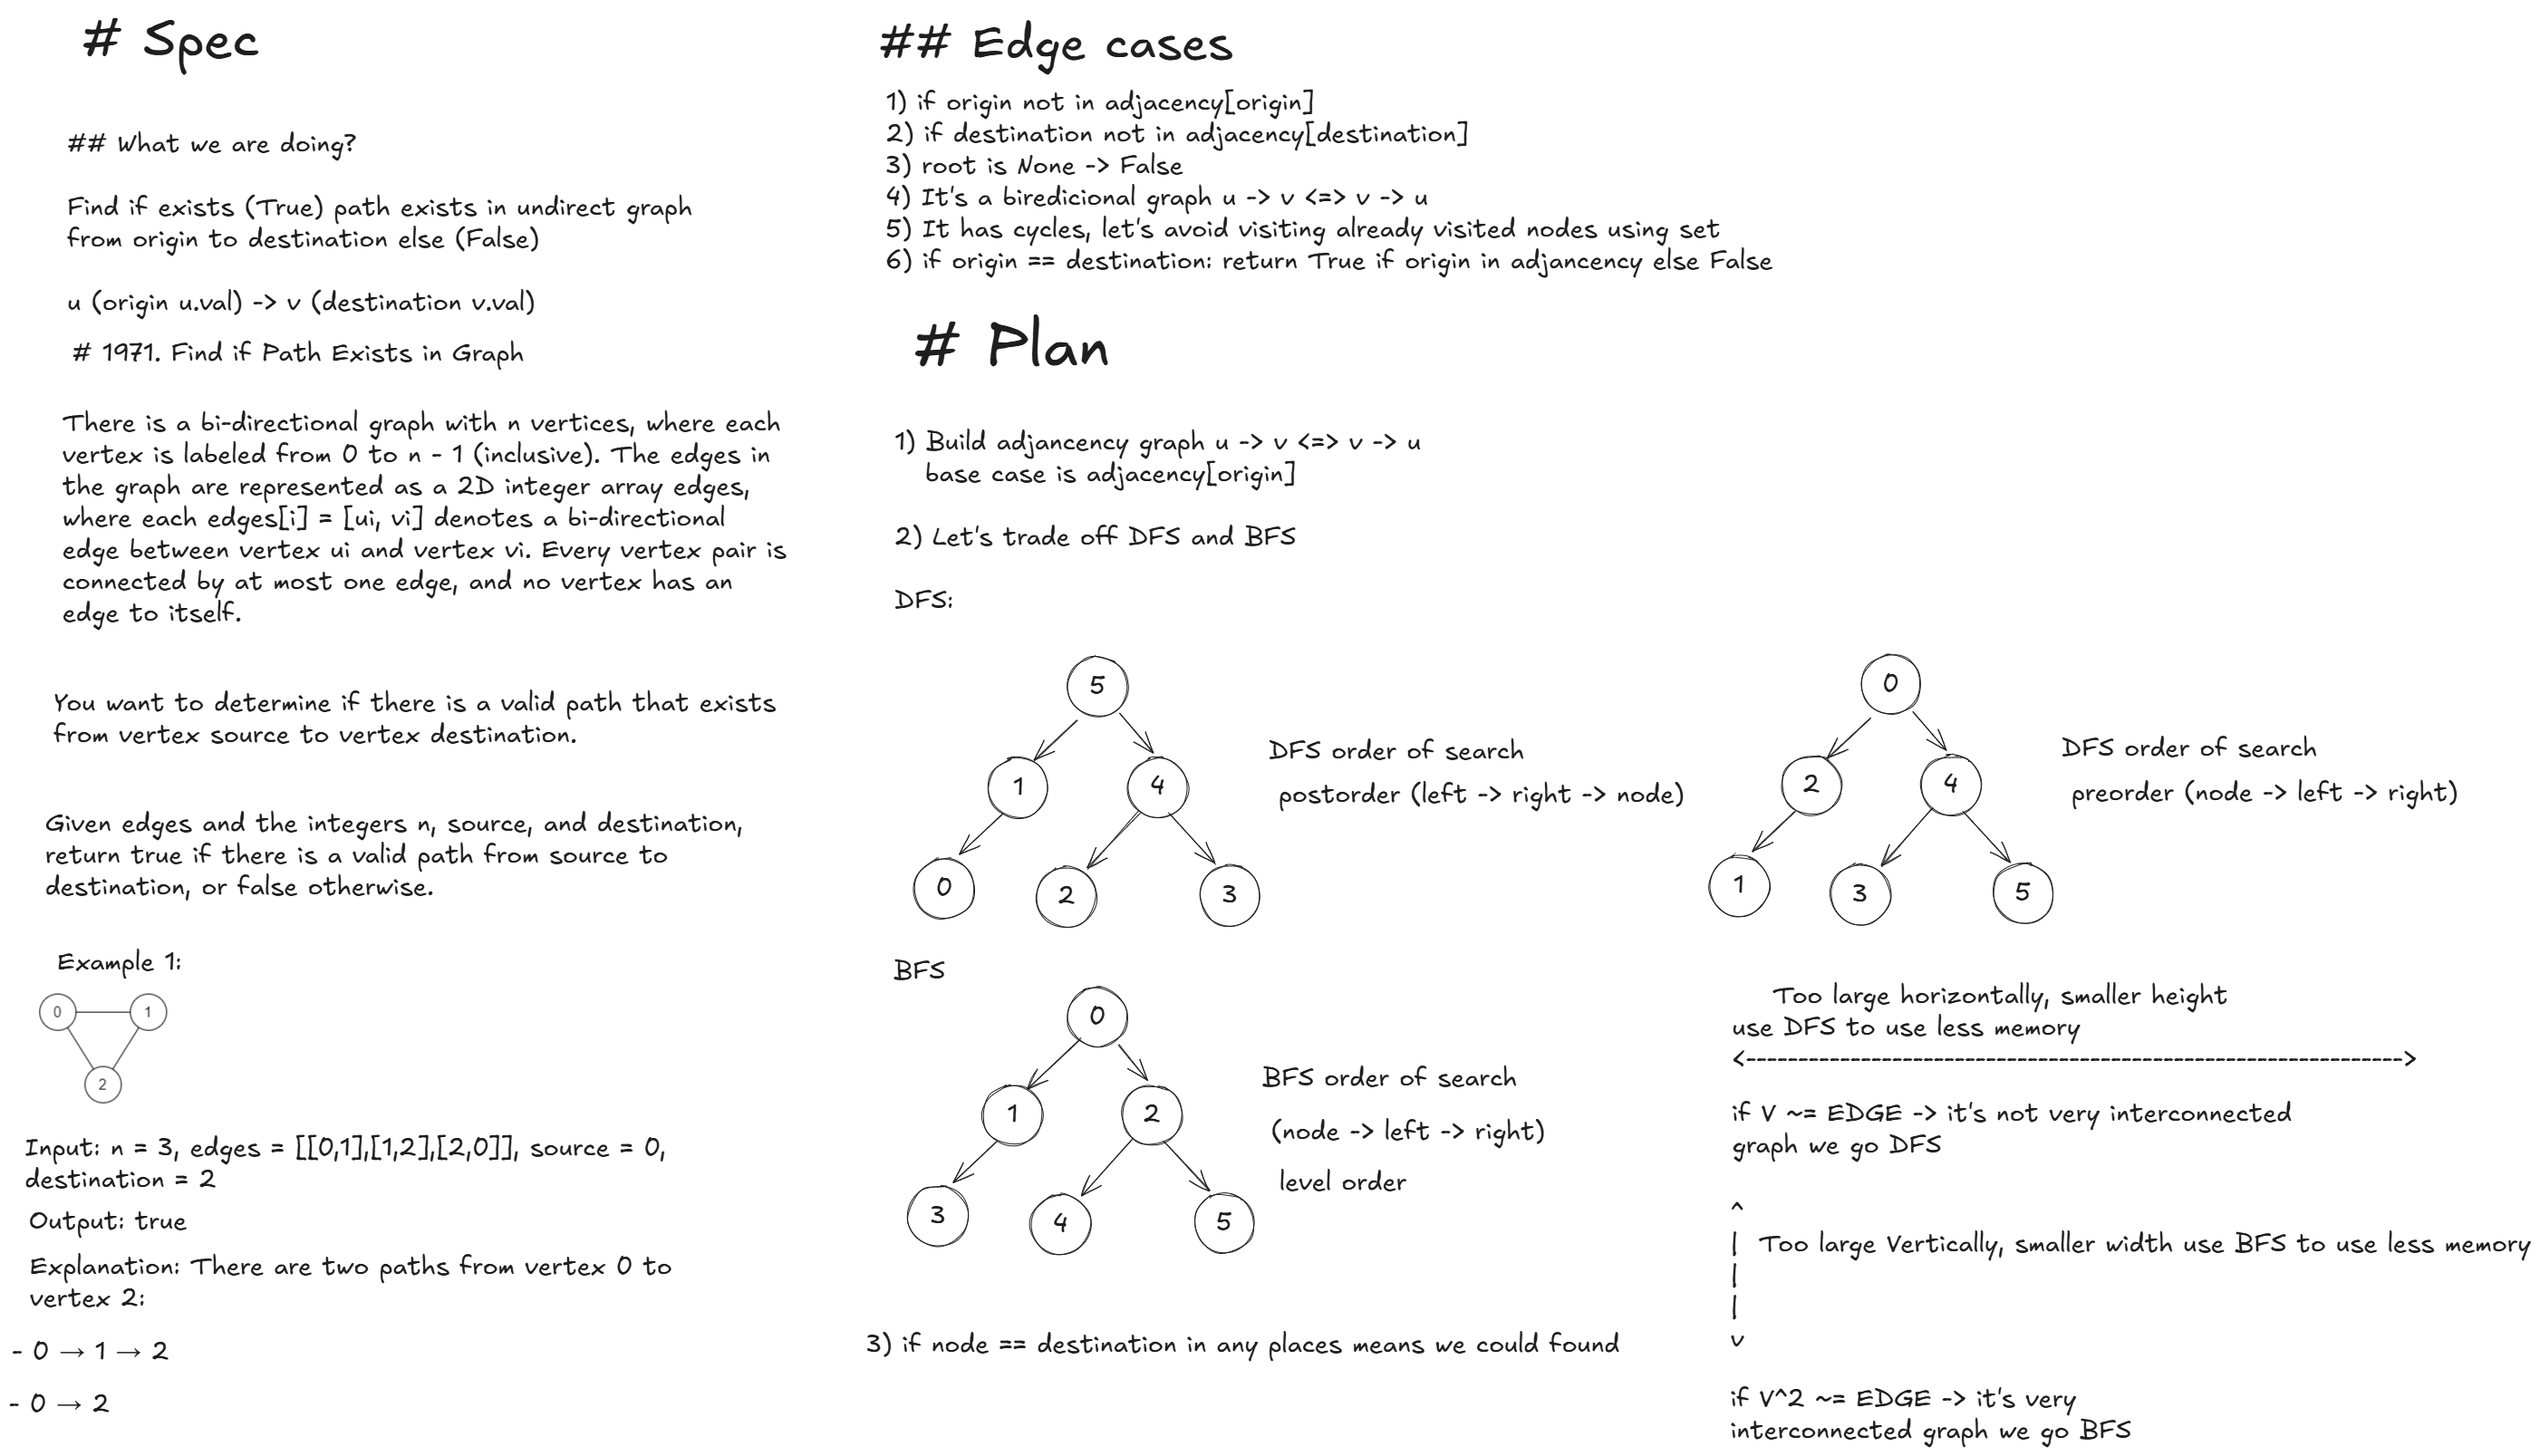

In [ ]:
from typing import List

class Solution:
    def validPath(self, n: int, edges: List[List[int]], source: int, destination: int) -> bool:
        # Se source == destination, há caminho trivial
        if source == destination:
            return True
        
        # Criar adjacency list corretamente (dicionário de LISTAS)
        adjacency = {i: [] for i in range(n)}
        
        for a, b in edges:
            adjacency[a].append(b)
            adjacency[b].append(a)
        
        # Começar com source já visitado
        visited = {source}
        stack = [source]
        
        while stack:
            node = stack.pop()
            if node == destination:
                return True
            for neighbor in adjacency[node]:
                if neighbor not in visited:
                    visited.add(neighbor)
                    stack.append(neighbor)
        
        return False


### Problemas no código anterior:

1. **Adjacency list errada**: `adjacency[a] = b` só salva o ÚLTIMO vizinho
   - Correto: `adjacency[a].append(b)` (lista de vizinhos)

2. **Não marcar source como visitado**: Causa loop infinito
   - Correto: `visited = {source}`

3. **Erro de KeyError**: Nó isolado não está em adjacency
   - Correto: Inicializar com `{i: [] for i in range(n)}`

**Complexidade:**
- **Tempo**: O(V + E) onde V = vértices, E = arestas (DFS)
- **Espaço**: O(V) (adjacency list + visited set + stack)

In [7]:
# Test Cases
sol = Solution()

# Test 1: Caminho existe - [[0,1],[1,2],[2,0]], 0 -> 2
print("Test 1: Existem múltiplos caminhos")
n = 3
edges = [[0,1], [1,2], [2,0]]
result = sol.validPath(n, edges, source=0, destination=2)
print(f"  n={n}, edges={edges}, source=0, dest=2")
print(f"  Resultado: {result} (esperado: True) ✓" if result else f"  Resultado: {result} (esperado: True) ✗")

# Test 2: Sem caminho - [[0,1],[0,2],[3,5],[5,4],[4,3]], 0 -> 5
print("\nTest 2: Grafo desconectado")
n = 6
edges = [[0,1], [0,2], [3,5], [5,4], [4,3]]
result = sol.validPath(n, edges, source=0, destination=5)
print(f"  n={n}, edges={edges}")
print(f"  source=0, dest=5")
print(f"  Resultado: {result} (esperado: False) ✓" if not result else f"  Resultado: {result} (esperado: False) ✗")

# Test 3: Source == Destination
print("\nTest 3: Source == Destination")
n = 1
edges = []
result = sol.validPath(n, edges, source=0, destination=0)
print(f"  n={n}, edges={edges}, source=0, dest=0")
print(f"  Resultado: {result} (esperado: True) ✓" if result else f"  Resultado: {result} (esperado: True) ✗")

# Test 4: Nó isolado
print("\nTest 4: Nó isolado")
n = 2
edges = [[0,1]]
result = sol.validPath(n, edges, source=1, destination=0)
print(f"  n={n}, edges={edges}, source=1, dest=0")
print(f"  Resultado: {result} (esperado: True) ✓" if result else f"  Resultado: {result} (esperado: True) ✗")


Test 1: Existem múltiplos caminhos


TypeError: 'int' object is not iterable